In [1]:
import os
import rasterio
import json
import numpy as np

import matplotlib.pyplot as plt
from scipy.optimize import bisect

In [2]:
def displacement(logky, logpga, M=None, logpgv=None, model="scalar"):
    """ Calculation of ground displacements
    Implementation of the statistical model for ground displacements of natural slopes subject to earthquakes 
    given in [1]. Note: The statistical model is develpped for subaerial conditions.
    
    Parameters:
        logky: float or ndarray 
            Log (Base 10) of Yield acceleration calculated using infinite slope analysis [g].
        logpga: float or ndarray. Same dimension as ky.
            Log (Base 10) of Peak ground acceleration of the event [g]. 
        M: float
            moment magnitude of the event.
        logpgv: float or ndarray. Same dimension as ky.
            Log (Base 10) of Peak ground velocity of the event [cm/s].
        model: string
            Different models. Options are "scalar" or "vector". If "scalar", then M must be supplied. 
            If "vector", then pgv must be supplied. Default is "scalar".
        
    Returns:
        Log of displacements [cm], Log of standard_deviation: float or ndarray, float or ndarray
        Logarithm of estimated displacements and associated standard deviation. 
        Standard deviation of lognormal multiplicative noise (as a function of ky/pga).  
        
    1. Rathje and Saygili, ‘Probabilistic Assessment of Earthquake-Induced Sliding Displacements of Natural Slopes’.
    """
    ky_pga_ratio = 10**(logky - logpga)
    logscale_factor = np.log10(np.exp(1))
    lnpga = logpga/logscale_factor
    
    if model == "scalar":
        a = [-29.06, 42.49, - 19.64,-4.85, 4.89] # polynomial coefficients.
        ln_d = np.where(ky_pga_ratio < 1., np.polyval(a, ky_pga_ratio) + 0.72*lnpga + 0.89*(M-6), 0.)
        sigma_ln = np.where(ky_pga_ratio < 1., np.polyval([-0.539, 0.789, 0.732], ky_pga_ratio), 0.)
    elif model == "vector":
        lnpgv = logpgv/np.log10(np.exp(1))
        a = [-30.5, 44.75, -20.84, -4.58, -1.56]
        ln_d = np.where(ky_pga_ratio < 1., np.polyval(a, ky_pga_ratio) - 0.64*lnpga + 1.55*lnpgv, 0)
        sigma_ln = np.where(ky_pga_ratio, 0.405 + 0.524*(ky_pga_ratio), 0.)
    return(ln_d*logscale_factor, sigma_ln*logscale_factor)

In [3]:
def f(logky):
    logd, logsigma = displacement(logky=logky, logpga=logpga, M=M)
    return(logd - np.log10(delta))

In [4]:
logpga = -0.6
M = 8.

selection_criteria = []
for delta in [3., 5., 10., 50]:
    root_logky = bisect(f, -2, 1)
    print(root_logky)
    
    selection_criteria.append({"root_logky": root_logky, "delta": delta, "logpga": logpga, "M":M})

-0.8210979085647523
-0.8744368531220061
-0.9610352866416179
-1.2285661379823978


In [5]:
logpgas = np.log10([0.6, 1, 1.5])
delta = 5.
print("pga: {}".format(10**logpga))
M = 8.
logky = np.linspace(-5,1,200000)

selection_criteria = []
for logpga in logpgas:
    #print(displacement(logky=logky, logpga=logpga, M=M)[0])
    more_than_delta = displacement(logky=logky, logpga=logpga, M=M)[0] > np.log10(delta)
    root_logky = logky[more_than_delta][-1] # Biggest log yield acelleration with displacement larger than delta.
    
    selection_criteria.append({"root_logky": root_logky, "delta": delta, "logpga": logpga, "M":M})

pga: 0.251188643150958


In [6]:
selection_criteria

[{'root_logky': np.float64(-0.43226716133580645),
  'delta': 5.0,
  'logpga': np.float64(-0.2218487496163564),
  'M': 8.0},
 {'root_logky': np.float64(-0.18002590012950037),
  'delta': 5.0,
  'logpga': np.float64(0.0),
  'M': 8.0},
 {'root_logky': np.float64(0.016685083425417524),
  'delta': 5.0,
  'logpga': np.float64(0.17609125905568124),
  'M': 8.0}]

In [7]:
# Extract areas using the Cummulative distribution of logky.
np.array([params["root_logky"] + params["logpga"] for params in selection_criteria])

array([-0.65411591, -0.1800259 ,  0.19277634])

# Run through each slopeunit and generate volume stats.

Intersect with fos quantiles, and select largest connected component.

Calculate Grilli-Watts approximation and filter away irrelevant volumes.
Volume metadata: Slopeunit, yield_threshold, probabilty_threshold.
Averaged values: Area, depth, (thickness), slope.

In [8]:
def read_tif(fname):
    "Read .tif data and profile using rasterio."
    #logger.info(f"Read file: {fname}")
    with rasterio.open(fname) as src:
        #data = np.ma.masked_equal(src.read(1), src.nodata)
        data = src.read(1)
        msk = np.where(src.read(1) == src.nodata, False, True)
        profile = src.profile.copy()
    return data, msk, profile

def write_tif(fname, data, profile):
    "Write .tif data and profile using rasterio."
    #logger.info(f"Write file: {fname}")
    with rasterio.open(fname, 'w', **profile) as dst:
        dst.write(data, 1)


In [9]:
# load json file
cumulative_dir = "/home/ebr/projects/release-volume-sampler/generated/messina_001/volume_selection/cummulative"
volumes_dir = "/home/ebr/projects/release-volume-sampler/generated/messina_001/volume_selection"

with open(os.path.join(volumes_dir, 'selection_criteria.json'), 'r') as f:
    selection_criteria = json.load(f)

with open(os.path.join(cumulative_dir, "content.json"),'r') as f:
    content = json.load(f)

cummulative_yield_probs = []
# Read all rasters and store the data
for i,c in enumerate(content):
    raster_path = os.path.join(cumulative_dir, c["file"])
    raster_data, msk, profile = read_tif(raster_path)
    cummulative_yield_probs.append(raster_data)



In [10]:
cummulative_yield_prob = np.average(np.stack(cummulative_yield_probs), weights=[1./3, 1./3, 1.3], axis=0)

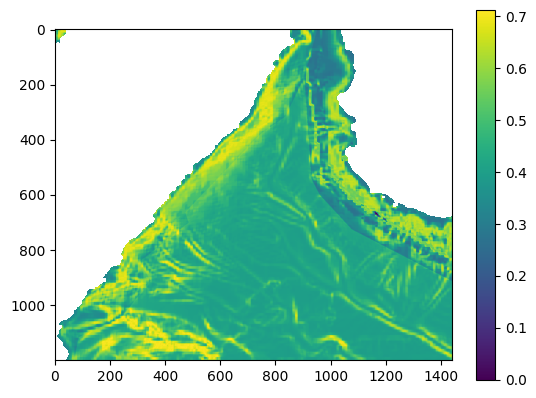

In [11]:
plt.imshow(cummulative_yield_prob)
plt.colorbar()

In [12]:
np.sum()
plt.imshow()

TypeError: sum() missing 1 required positional argument: 'a'

In [13]:
bathy_file = "/home/ebr/projects/release-volume-sampler/input/bathy/messina_001/bathy_truncated.tif"
slopeunits_file = "/home/ebr/projects/release-volume-sampler/generated/slopeunits/slumap.tif"
slope_file = "/home/ebr/projects/release-volume-sampler/generated/messina_001/slope.tif"
pixel_areas_file = "/home/ebr/projects/release-volume-sampler/generated/messina_001/pixel_areas.tif"

In [14]:
slopeunits, slopeunits_msk, slopeunits_profile = read_tif(slopeunits_file)
bathy, bathy_msk, bathy_profile = read_tif(bathy_file)
slope, slope_msk, slope_profile = read_tif(slope_file)
pixel_areas, pixel_areas_msk, pixel_areas_profile = read_tif(pixel_areas_file)

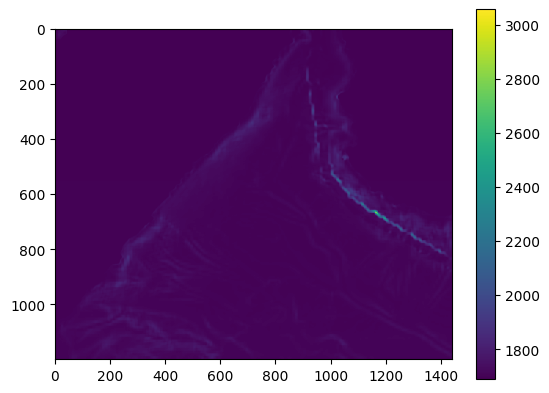

In [15]:
plt.imshow(pixel_areas)
plt.colorbar()

In [16]:
selection_criteria

[{'logky': -1.2093910469552345,
  'delta': 29.999999999999996,
  'pga': 0.29999999999999993,
  'M': 7.0},
 {'logky': -0.7997989989949952,
  'delta': 29.999999999999996,
  'pga': 0.6,
  'M': 7.0},
 {'logky': -0.5111375556877782,
  'delta': 29.999999999999996,
  'pga': 1.0,
  'M': 7.0}]

In [17]:
from scipy.ndimage import label
import sys

logfos_thresholds = [0.3, 0.5, 0.8]
release_volumes = []
output_folder = "/home/ebr/projects/release-volume-sampler/generated/messina_001/volume_selection"
logfos_quantile_file = "/home/ebr/projects/release-volume-sampler/generated/messina_001/fos/quantiles/fos_quantiles_2.tif" # 0.5 quantile

logfos, logfos_msk, logfos_profile = read_tif(logfos_quantile_file)
release_area_rasters = []

def get_release_area(slopeunit_nr, logfos_threshold):
    area = np.logical_and(slopeunits == slopeunit_nr, logfos < logfos_threshold)
    # Find connected components
    labeled_array, num_features = label(area)
    
    # Select largest connected component (Perhaps check the remaining areas..)
    #component_areas = [np.sum(pixel_areas[labeled_array == component_nr]) for component_nr in range(num_features)]
    return(labeled_array == 1) # Largest area is always labelled 1.

for i, logfos_threshold in enumerate(logfos_thresholds):
    release_area_raster = np.empty(bathy.shape)
    release_area_raster[:] = np.nan

    for slopeunit_nr in set(slopeunits[slopeunits_msk]):
        release_area = get_release_area(slopeunit_nr, logfos_threshold)
        release_area_raster[release_area] = slopeunit_nr
        release_volumes.append({
                "slopeunit": slopeunit_nr,
                "area": np.sum(pixel_areas[release_area]),
                "mean_depth": np.mean(bathy[release_area]),
                "mean_slope": np.mean(slope[release_area]),
        })
    release_area_rasters.append(release_area_raster)
    write_tif(os.path.join(output_folder, f"release_areas_{i}.tif"), release_area_raster, bathy_profile)

/home/ebr/.cache/pypoetry/virtualenvs/release-volume-sampler-LsGdq2JB-py3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ebr/.cache/pypoetry/virtualenvs/release-volume-sampler-LsGdq2JB-py3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


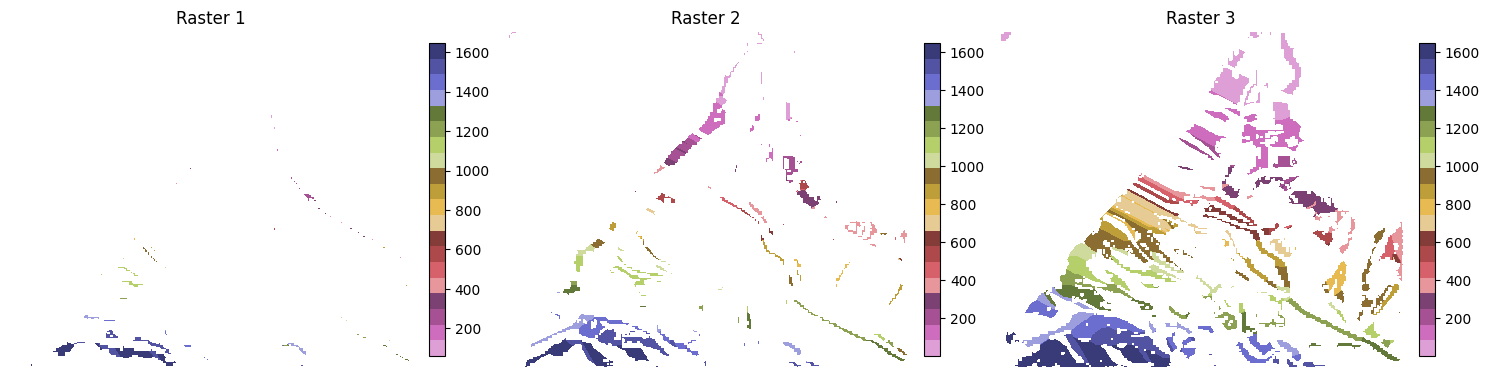

In [18]:
# Number of rasters to plot
num_rasters = len(release_area_rasters)

# Set up a grid for subplots (1 row, num_rasters columns)
fig, axes = plt.subplots(1, num_rasters, figsize=(5 * num_rasters, 5))

# Loop over each raster and subplot axis
for i, raster_data in enumerate(release_area_rasters):
        ax = axes[i] if num_rasters > 1 else axes  # Handle single subplot case
        cax = ax.imshow(raster_data, cmap='tab20b_r')
        ax.set_title(f"Raster {i+1}")
        ax.axis("off")
        fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.036, pad=0.04)

plt.tight_layout()
plt.show()


In [20]:
import pandas as pd
release_volumes_df = pd.DataFrame(release_volumes)

In [21]:
release_volumes_df

,slopeunit,area,mean_depth,mean_slope
0,1,0.000000e+00,NaN,NaN
1,2,0.000000e+00,NaN,NaN
2,3,0.000000e+00,NaN,NaN
3,4,0.000000e+00,NaN,NaN
4,5,0.000000e+00,NaN,NaN
...,...,...,...,...
1990,1641,8.586021e+03,-1033.439941,7.411580
1991,1642,3.233816e+06,-172.698547,7.400854
1992,1644,8.626943e+03,-1166.119995,9.419741
1993,1646,7.744798e+04,-1279.970947,8.383035


(array([1.698e+03, 1.140e+02, 6.900e+01, 2.800e+01, 2.900e+01, 2.600e+01,
        6.000e+00, 1.000e+01, 3.000e+00, 7.000e+00, 2.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([   0.        ,   95.72332001,  191.44664001,  287.16995239,
         382.89328003,  478.61660767,  574.33990479,  670.06323242,
         765.78656006,  861.5098877 ,  957.23321533, 1052.95654297,
        1148.67980957, 1244.40319824, 1340.12646484, 1435.84985352,
        1531.57312012, 1627.29638672, 1723.01977539, 1818.74304199,
        1914.46643066]),
 <BarContainer object of 20 artists>)

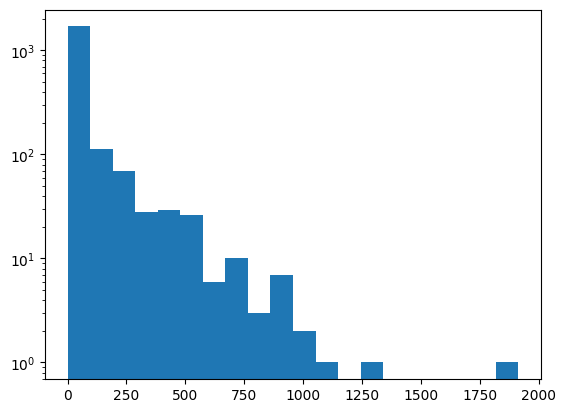

In [22]:
plt.hist(release_volumes_df.area/(100*100), bins=20, log=True)